# Phishing Link Detection - Exploratory Data Analysis

## 1. Problem Statement

Phishing adalah salah satu serangan siber paling umum yang digunakan untuk mencuri informasi sensitif pengguna. Project ini bertujuan membangun model Machine Learning yang mampu mengklasifikasikan URL sebagai **phishing** atau **legitimate**.

- **Dataset**: PhiUSIIL Phishing URL Dataset (UCI ML Repository)
- **Task**: Binary Classification
- **Target**: `label` — Phishing (0) vs Legitimate (1)

## 2. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set_palette('Set2')

## 3. Load Dataset

In [2]:
df = pd.read_csv('../Data/raw/PhiUSIIL_Phishing_URL_Dataset.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (235795, 56)


,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


## 4. Data Understanding

### 4.1 Dataset Structure

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FILENAME                    235795 non-null  str    
 1   URL                         235795 non-null  str    
 2   URLLength                   235795 non-null  int64  
 3   Domain                      235795 non-null  str    
 4   DomainLength                235795 non-null  int64  
 5   IsDomainIP                  235795 non-null  int64  
 6   TLD                         235795 non-null  str    
 7   URLSimilarityIndex          235795 non-null  float64
 8   CharContinuationRate        235795 non-null  float64
 9   TLDLegitimateProb           235795 non-null  float64
 10  URLCharProb                 235795 non-null  float64
 11  TLDLength                   235795 non-null  int64  
 12  NoOfSubDomain               235795 non-null  int64  
 13  HasObfuscation           

In [4]:
# cek kolom non-numeric
non_numeric = df.select_dtypes(exclude='number').columns.tolist()
print(f'Kolom non-numeric: {non_numeric}')

Kolom non-numeric: ['FILENAME', 'URL', 'Domain', 'TLD', 'Title']


### 4.2 Data Quality Check

In [5]:
# cek missing values
print('Missing values per kolom:')
print(df.isnull().sum()[df.isnull().sum() > 0])

if df.isnull().sum().sum() == 0:
    print('Tidak ada missing values.')

Missing values per kolom:
Series([], dtype: int64)
Tidak ada missing values.


In [6]:
# cek duplikat
dup_count = df.duplicated().sum()
print(f'Jumlah baris duplikat: {dup_count}')

Jumlah baris duplikat: 0


### 4.3 Klasifikasi Fitur

Dataset memiliki 56 kolom yang bisa dikelompokkan menjadi:

- **Metadata** (5): `FILENAME`, `URL`, `Domain`, `TLD`, `Title` — bukan fitur untuk modeling
- **URL Structural** (12): `URLLength`, `DomainLength`, `IsDomainIP`, `NoOfSubDomain`, dll
- **URL Statistical** (10): `URLSimilarityIndex`, `CharContinuationRate`, `TLDLegitimateProb`, dll
- **Page Content** (13): `LineOfCode`, `HasTitle`, `NoOfImage`, `NoOfCSS`, `NoOfJS`, dll
- **Security & Interaction** (12): `Robots`, `NoOfPopup`, `HasExternalFormSubmit`, dll
- **Reference** (3): `NoOfSelfRef`, `NoOfEmptyRef`, `NoOfExternalRef`
- **Target** (1): `label`

### 4.4 Statistik Deskriptif

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
URLLength,235795.0,34.573095,41.314153,13.000000,23.000000,27.000000,34.000000,6.097000e+03
DomainLength,235795.0,21.470396,9.150793,4.000000,16.000000,20.000000,24.000000,1.100000e+02
IsDomainIP,235795.0,0.002706,0.051946,0.000000,0.000000,0.000000,0.000000,1.000000e+00
URLSimilarityIndex,235795.0,78.430778,28.976055,0.155574,57.024793,100.000000,100.000000,1.000000e+02
CharContinuationRate,235795.0,0.845508,0.216632,0.000000,0.680000,1.000000,1.000000,1.000000e+00
TLDLegitimateProb,235795.0,0.260423,0.251628,0.000000,0.005977,0.079963,0.522907,5.229071e-01
URLCharProb,235795.0,0.055747,0.010587,0.001083,0.050747,0.057970,0.062875,9.082366e-02
TLDLength,235795.0,2.764456,0.599739,2.000000,2.000000,3.000000,3.000000,1.300000e+01
NoOfSubDomain,235795.0,1.164758,0.600969,0.000000,1.000000,1.000000,1.000000,1.000000e+01
HasObfuscation,235795.0,0.002057,0.045306,0.000000,0.000000,0.000000,0.000000,1.000000e+00


---

## 5. Exploratory Data Analysis

### 5.1 Distribusi Target Variable

Distribusi target:
  Phishing: 100,945 (42.8%)
  Legitimate: 134,850 (57.2%)


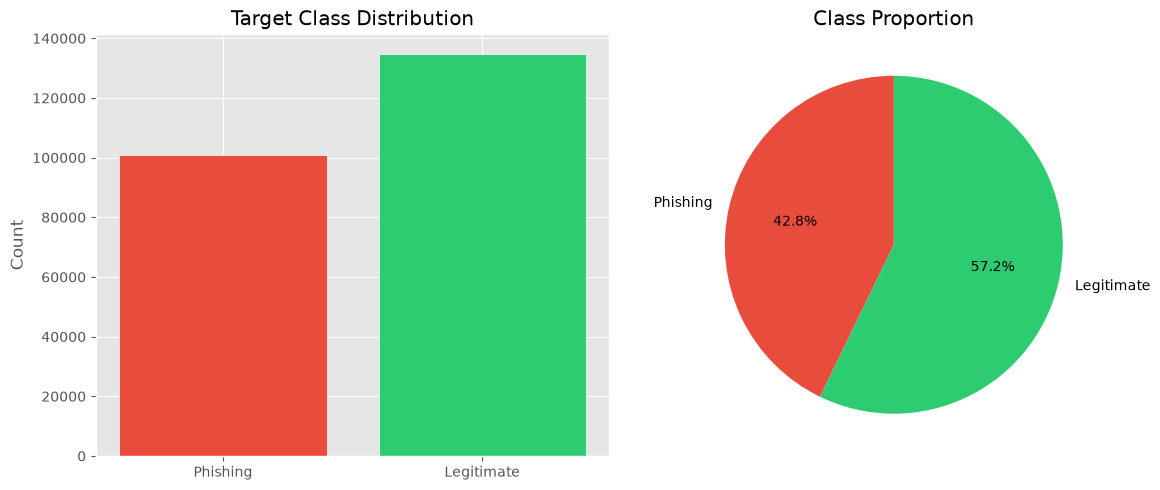

In [8]:
label_counts = df['label'].value_counts().sort_index()
label_names = {0: 'Phishing', 1: 'Legitimate'}

print('Distribusi target:')
for val, count in label_counts.items():
    pct = count / len(df) * 100
    print(f'  {label_names[val]}: {count:,} ({pct:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# bar chart
colors = ['#e74c3c', '#2ecc71']
axes[0].bar(['Phishing', 'Legitimate'], label_counts.values,
            color=colors, edgecolor='white')
axes[0].set_title('Target Class Distribution')
axes[0].set_ylabel('Count')

# pie chart
axes[1].pie(label_counts.values,
            labels=['Phishing', 'Legitimate'],
            autopct='%1.1f%%', colors=colors,
            startangle=90)
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.savefig('../Artifacts/figures/01_target_distribution.png')
plt.show()

### 5.2 URL Structural Features

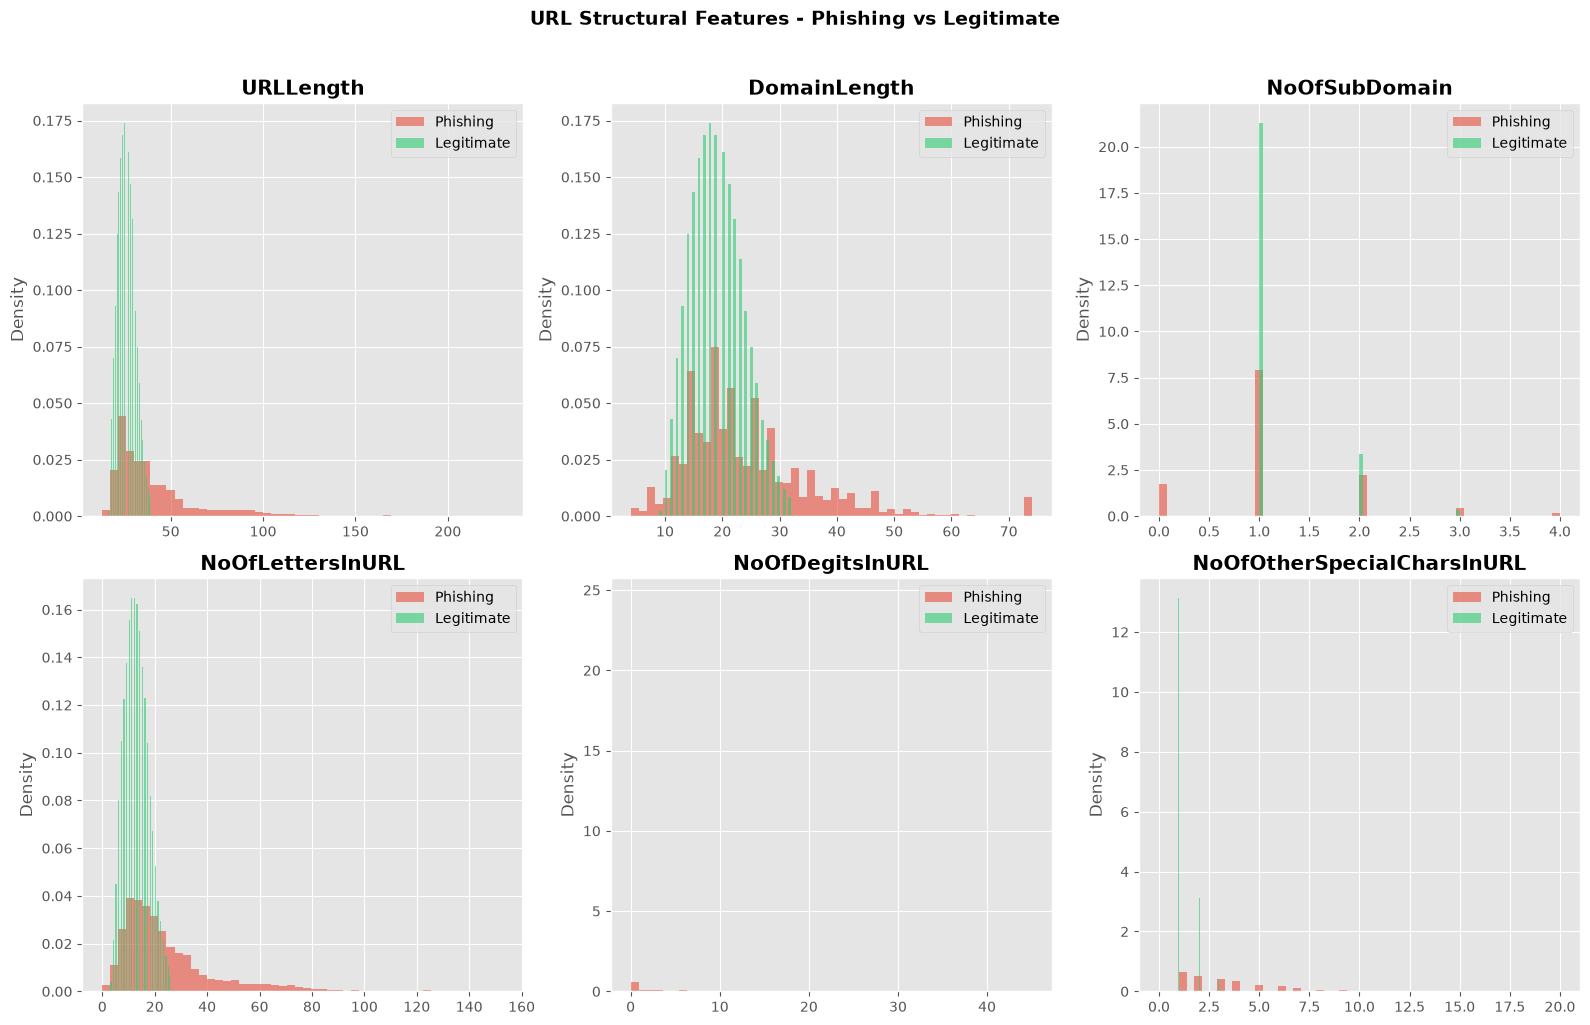

In [9]:
url_features = ['URLLength', 'DomainLength', 'NoOfSubDomain',
                'NoOfLettersInURL', 'NoOfDegitsInURL',
                'NoOfOtherSpecialCharsInURL']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(url_features):
    ax = axes[i]
    # clip outlier biar histogramnya keliatan
    for label_val, color, name in [(0, '#e74c3c', 'Phishing'),
                                   (1, '#2ecc71', 'Legitimate')]:
        data = df[df['label'] == label_val][feat]
        data = data[data <= data.quantile(0.99)]
        ax.hist(data, bins=50, alpha=0.6, label=name,
                color=color, density=True)
    ax.set_title(feat, fontweight='bold')
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('URL Structural Features - Phishing vs Legitimate',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../Artifacts/figures/02_url_structural_features.png',
            bbox_inches='tight')
plt.show()

### 5.3 URL Statistical Features

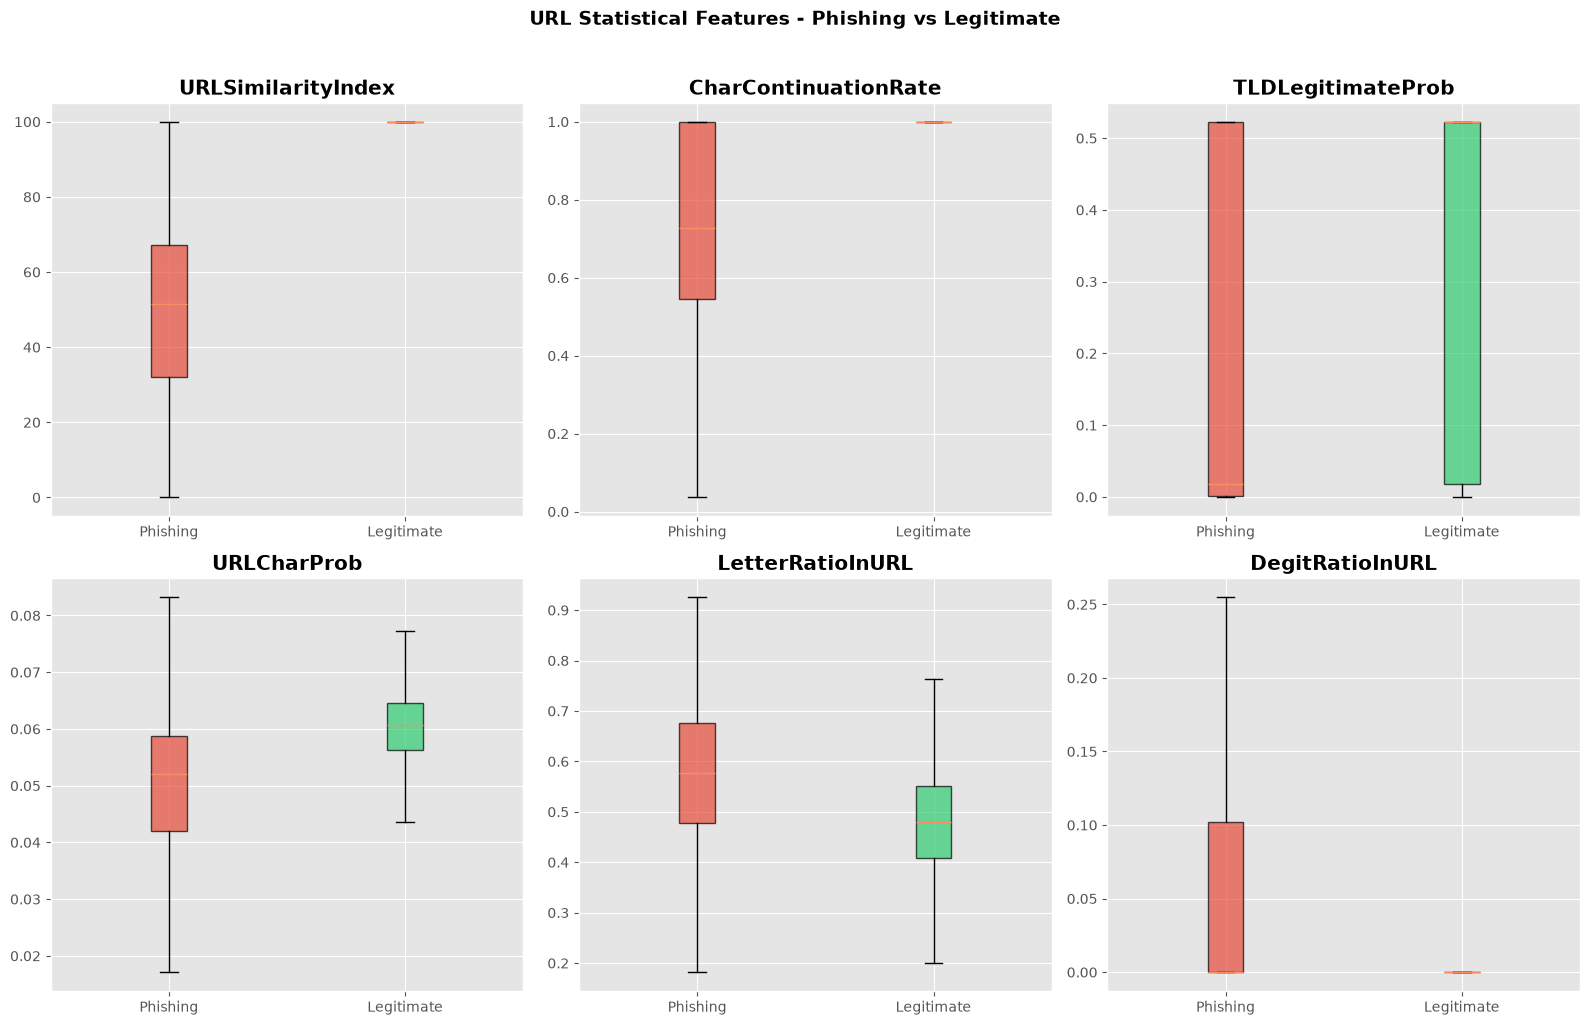

In [10]:
stat_features = ['URLSimilarityIndex', 'CharContinuationRate',
                 'TLDLegitimateProb', 'URLCharProb',
                 'LetterRatioInURL', 'DegitRatioInURL']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(stat_features):
    ax = axes[i]
    phishing = df[df['label'] == 0][feat]
    legit = df[df['label'] == 1][feat]

    bp = ax.boxplot([phishing, legit],
                    tick_labels=['Phishing', 'Legitimate'],
                    patch_artist=True, showfliers=False)
    bp['boxes'][0].set_facecolor('#e74c3c')
    bp['boxes'][1].set_facecolor('#2ecc71')
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_alpha(0.7)
    ax.set_title(feat, fontweight='bold')

plt.suptitle('URL Statistical Features - Phishing vs Legitimate',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../Artifacts/figures/03_url_statistical_features.png',
            bbox_inches='tight')
plt.show()

### 5.4 Binary Features vs Target

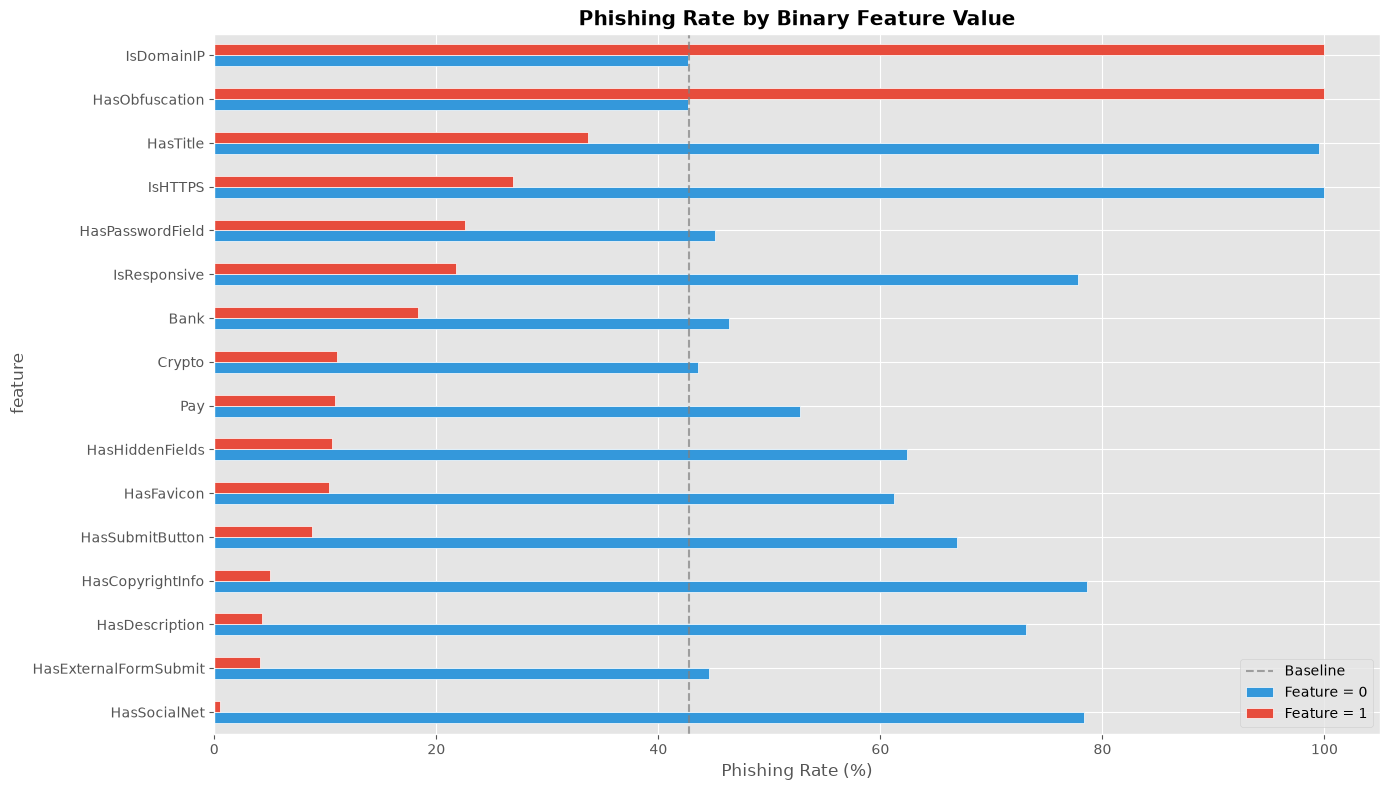

In [11]:
binary_features = ['IsDomainIP', 'IsHTTPS', 'HasObfuscation',
                   'HasTitle', 'HasFavicon', 'IsResponsive',
                   'HasDescription', 'HasCopyrightInfo',
                   'HasExternalFormSubmit', 'HasSocialNet',
                   'HasSubmitButton', 'HasHiddenFields',
                   'HasPasswordField', 'Bank', 'Pay', 'Crypto']

# hitung phishing rate tiap binary feature
phishing_rates = []
for feat in binary_features:
    for val in [0, 1]:
        subset = df[df[feat] == val]
        rate = (subset['label'] == 0).mean() * 100
        phishing_rates.append({
            'feature': feat, 'value': val,
            'phishing_rate': rate
        })

rates_df = pd.DataFrame(phishing_rates)
pivot = rates_df.pivot(index='feature', columns='value',
                       values='phishing_rate')
pivot.columns = ['Feature = 0', 'Feature = 1']
pivot = pivot.sort_values('Feature = 1', ascending=True)

fig, ax = plt.subplots(figsize=(14, 8))
pivot.plot(kind='barh', ax=ax, color=['#3498db', '#e74c3c'],
           edgecolor='white')
ax.set_xlabel('Phishing Rate (%)')
ax.set_title('Phishing Rate by Binary Feature Value',
             fontweight='bold')
ax.axvline(x=42.8, color='gray', linestyle='--',
           alpha=0.7, label='Baseline')
ax.legend()

plt.tight_layout()
plt.savefig('../Artifacts/figures/04_binary_features_phishing_rate.png',
            bbox_inches='tight')
plt.show()

### 5.5 Page Content Features

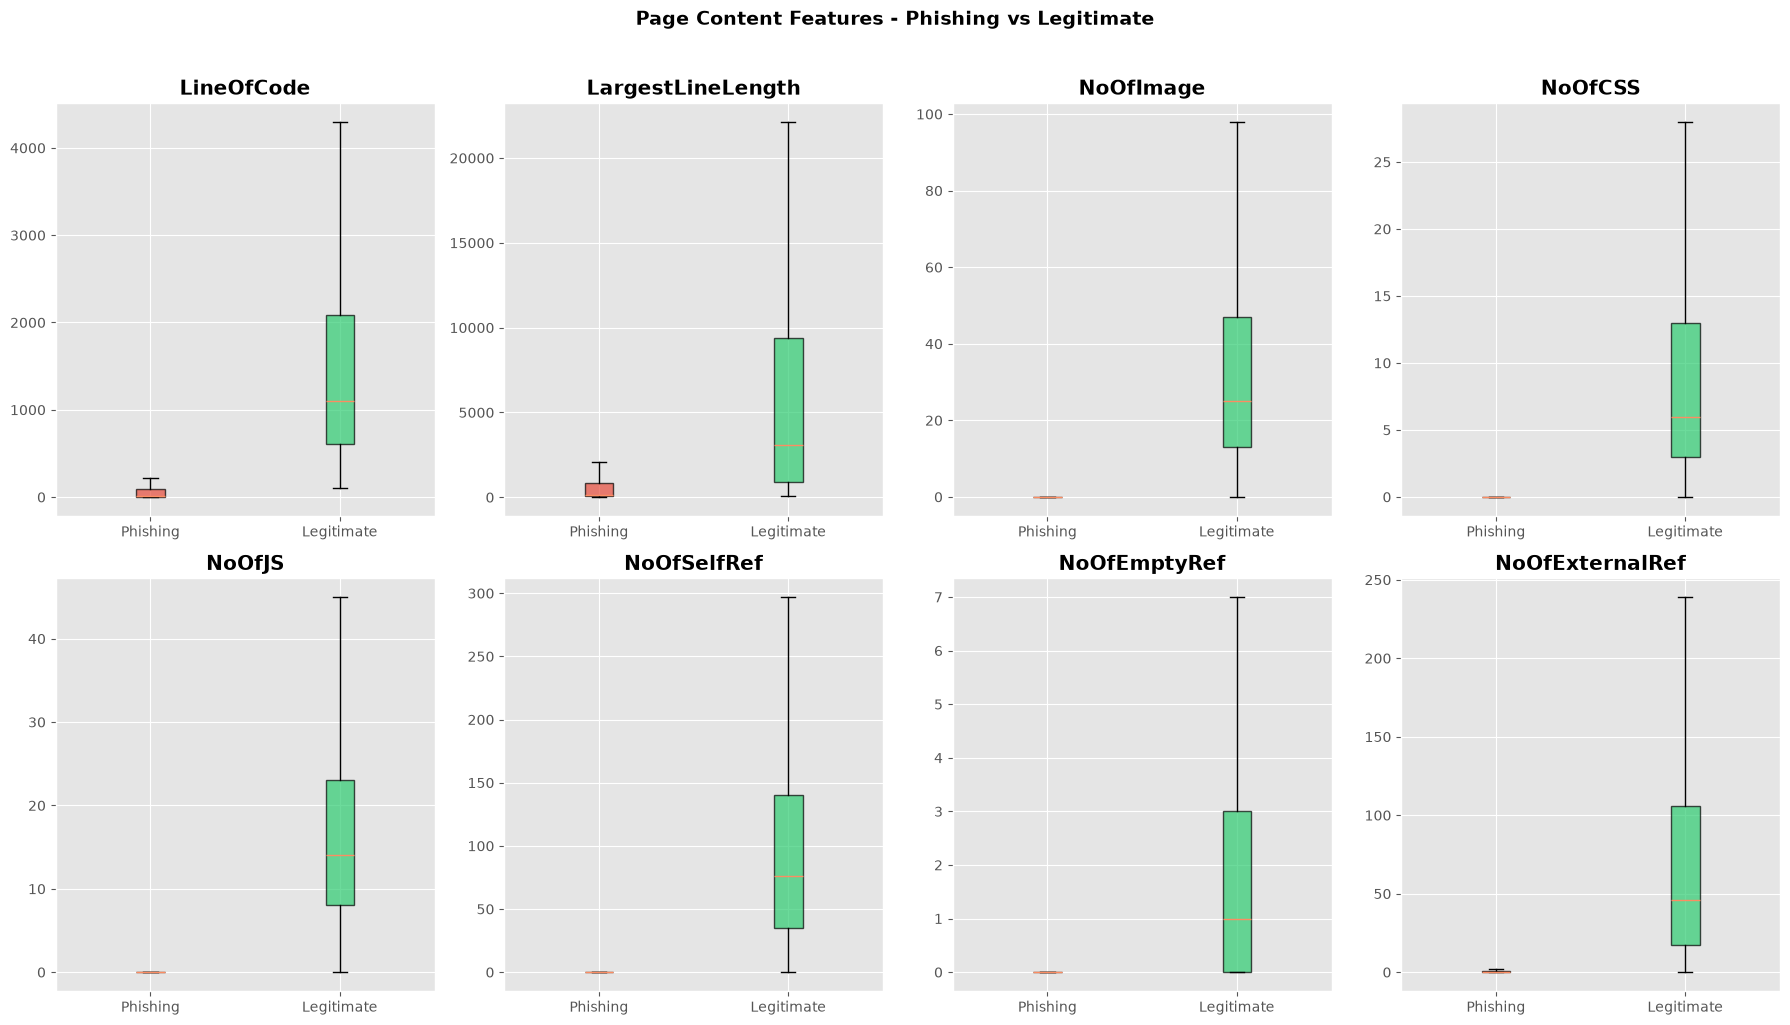

In [12]:
content_features = ['LineOfCode', 'LargestLineLength',
                    'NoOfImage', 'NoOfCSS', 'NoOfJS',
                    'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(content_features):
    ax = axes[i]
    phishing = df[df['label'] == 0][feat]
    legit = df[df['label'] == 1][feat]

    bp = ax.boxplot([phishing, legit],
                    tick_labels=['Phishing', 'Legitimate'],
                    patch_artist=True, showfliers=False)
    bp['boxes'][0].set_facecolor('#e74c3c')
    bp['boxes'][1].set_facecolor('#2ecc71')
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_alpha(0.7)
    ax.set_title(feat, fontweight='bold')

plt.suptitle('Page Content Features - Phishing vs Legitimate',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../Artifacts/figures/05_page_content_features.png',
            bbox_inches='tight')
plt.show()

### 5.6 Correlation Analysis

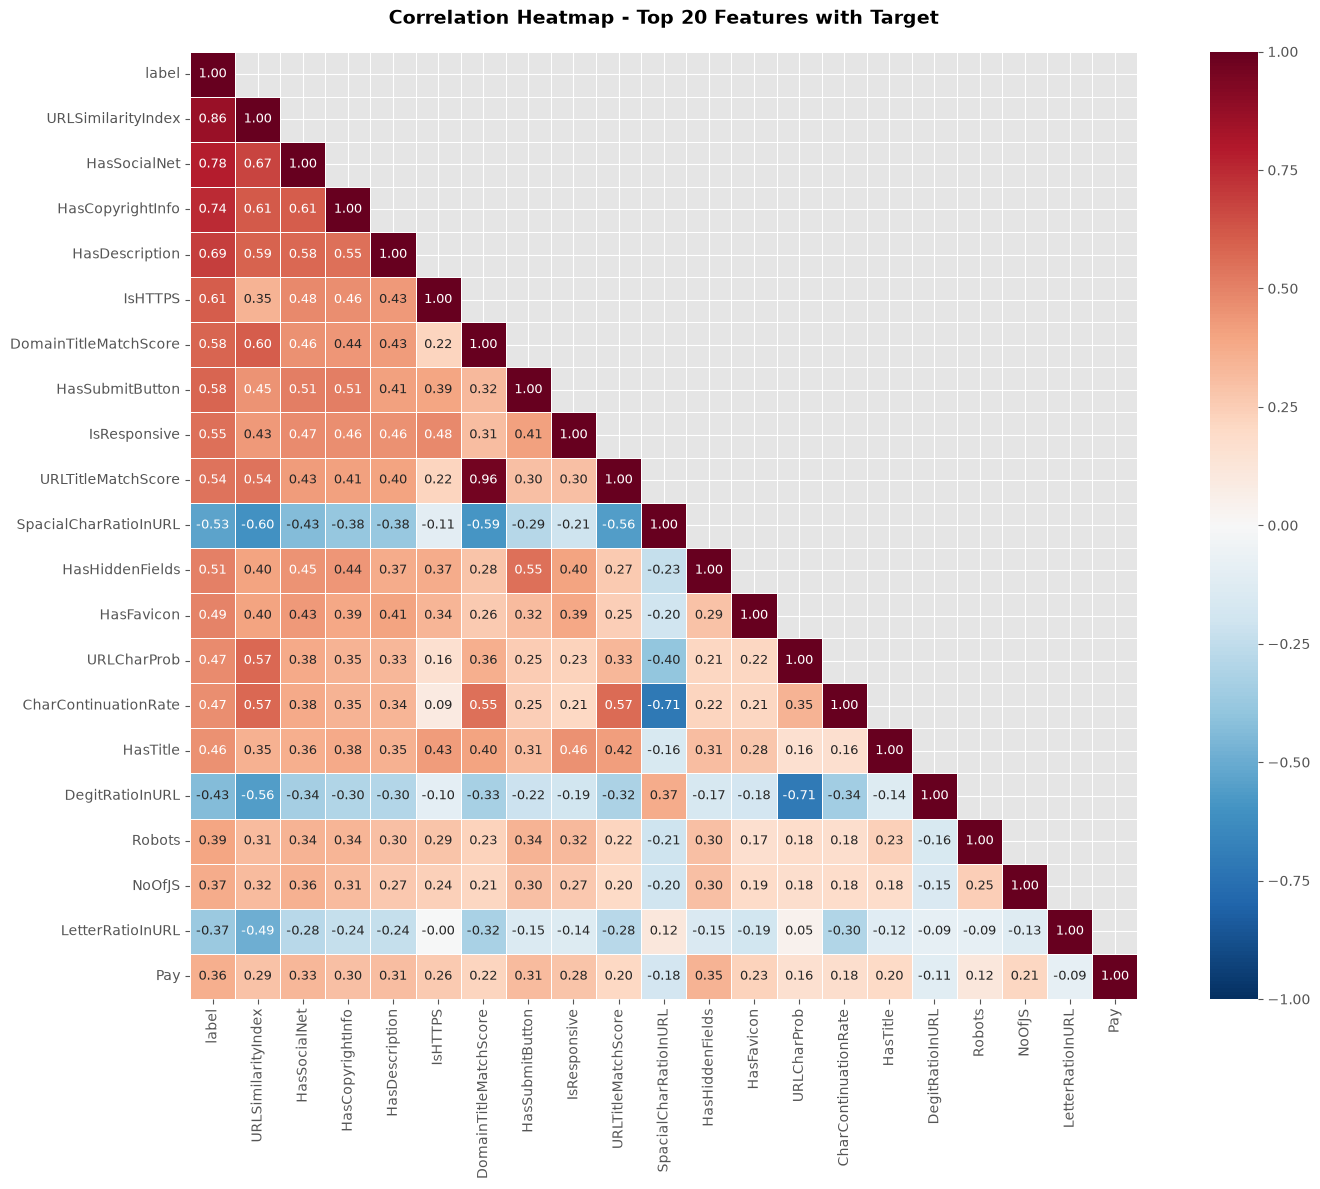

In [13]:
# hitung korelasi dari kolom numerik
numeric_cols = df.select_dtypes(include='number').columns.tolist()
corr_matrix = df[numeric_cols].corr()

# ambil top 20 fitur paling berkorelasi dengan label untuk visualisasi yang lebih rapi
top_corr_features = corr_matrix['label'].abs().sort_values(ascending=False).index[1:21].tolist()
features_to_plot = ['label'] + top_corr_features

# subset correlation matrix
sub_corr = corr_matrix.loc[features_to_plot, features_to_plot]

fig, ax = plt.subplots(figsize=(16, 12))
# k=1 agar diagonal self-correlation (1.0) tetap terlihat
mask = np.triu(np.ones_like(sub_corr, dtype=bool), k=1)

sns.heatmap(sub_corr, mask=mask, cmap='RdBu_r', annot=True, fmt='.2f',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            annot_kws={'size': 9}, ax=ax)
ax.set_title('Correlation Heatmap - Top 20 Features with Target',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('../Artifacts/figures/06_correlation_heatmap.png',
            bbox_inches='tight')
plt.show()

### 5.7 Korelasi Fitur dengan Target

Top 20 fitur paling berkorelasi dengan target:
URLSimilarityIndex       0.860358
HasSocialNet             0.784255
HasCopyrightInfo         0.743358
HasDescription           0.690232
IsHTTPS                  0.609132
DomainTitleMatchScore    0.584905
HasSubmitButton          0.578561
IsResponsive             0.548608
URLTitleMatchScore       0.539419
SpacialCharRatioInURL   -0.533537
HasHiddenFields          0.507731
HasFavicon               0.493711
URLCharProb              0.469749
CharContinuationRate     0.467735
HasTitle                 0.459725
DegitRatioInURL         -0.432032
Robots                   0.392620
NoOfJS                   0.373500
LetterRatioInURL        -0.367794
Pay                      0.359747
Name: label, dtype: float64


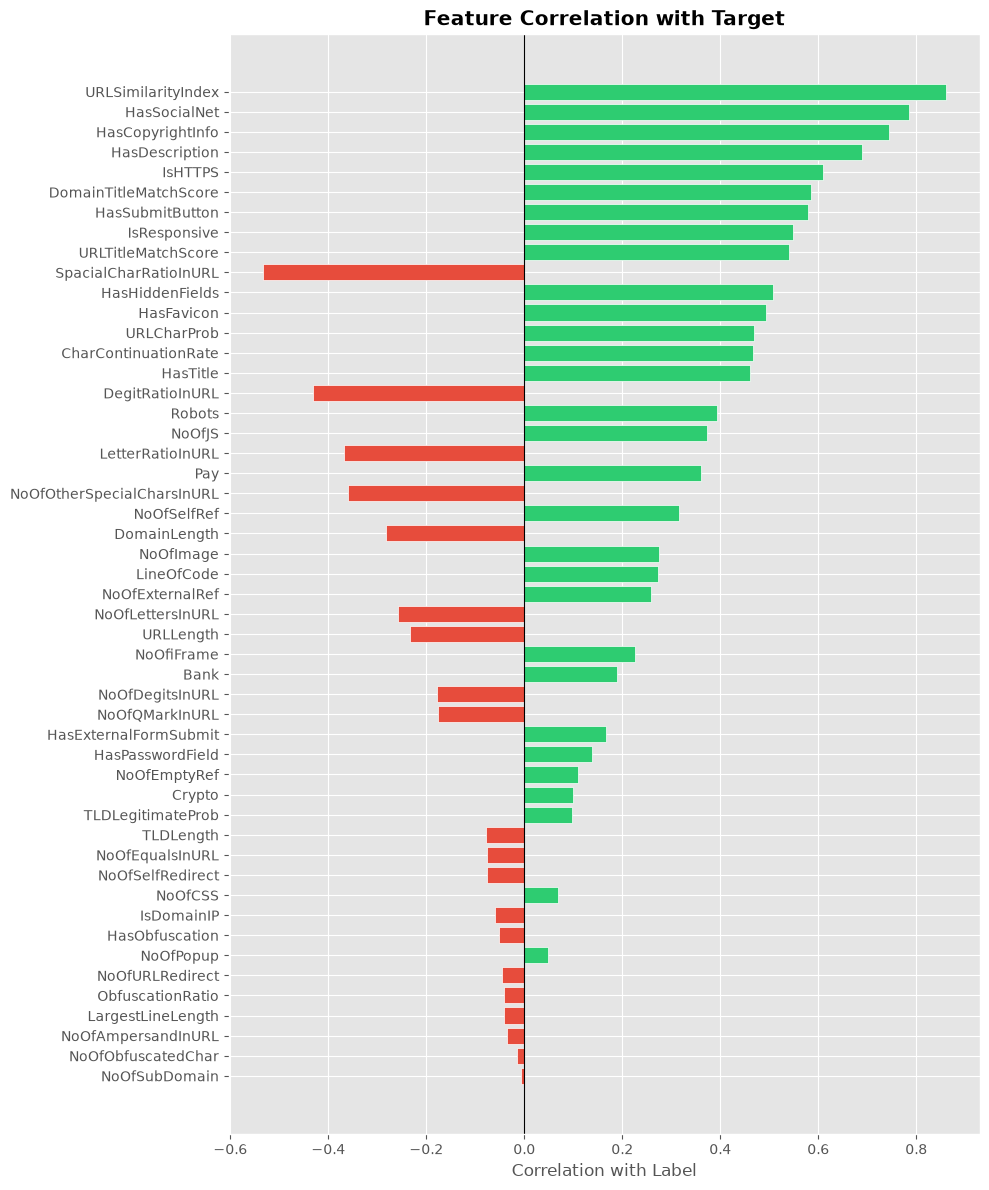

In [14]:
# korelasi semua fitur dengan label, diurutkan
target_corr = corr_matrix['label'].drop('label').sort_values(
    key=abs, ascending=False)

print('Top 20 fitur paling berkorelasi dengan target:')
print(target_corr.head(20))

# plot
fig, ax = plt.subplots(figsize=(10, 12))
colors = ['#e74c3c' if v < 0 else '#2ecc71'
          for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values,
        color=colors, edgecolor='white')
ax.set_xlabel('Correlation with Label')
ax.set_title('Feature Correlation with Target',
             fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../Artifacts/figures/07_feature_target_correlation.png',
            bbox_inches='tight')
plt.show()

### 5.8 Deteksi Multikolinearitas

In [15]:
# cari pasangan fitur dengan korelasi tinggi (|r| > 0.8)
threshold = 0.8
high_corr_pairs = []

cols = [c for c in numeric_cols if c != 'label']
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = corr_matrix.loc[cols[i], cols[j]]
        if abs(r) > threshold:
            high_corr_pairs.append({
                'Feature 1': cols[i],
                'Feature 2': cols[j],
                'Correlation': round(r, 4)
            })

high_corr_df = pd.DataFrame(high_corr_pairs)
high_corr_df = high_corr_df.sort_values('Correlation',
                                         key=abs, ascending=False)
print(f'Pasangan fitur dengan |r| > {threshold}:')
print(high_corr_df.to_string(index=False))

Pasangan fitur dengan |r| > 0.8:
            Feature 1          Feature 2  Correlation
DomainTitleMatchScore URLTitleMatchScore       0.9610
            URLLength   NoOfLettersInURL       0.9560
            URLLength    NoOfDegitsInURL       0.8358
      NoOfDegitsInURL    NoOfEqualsInURL       0.8060


### 5.9 Top Predictive Features

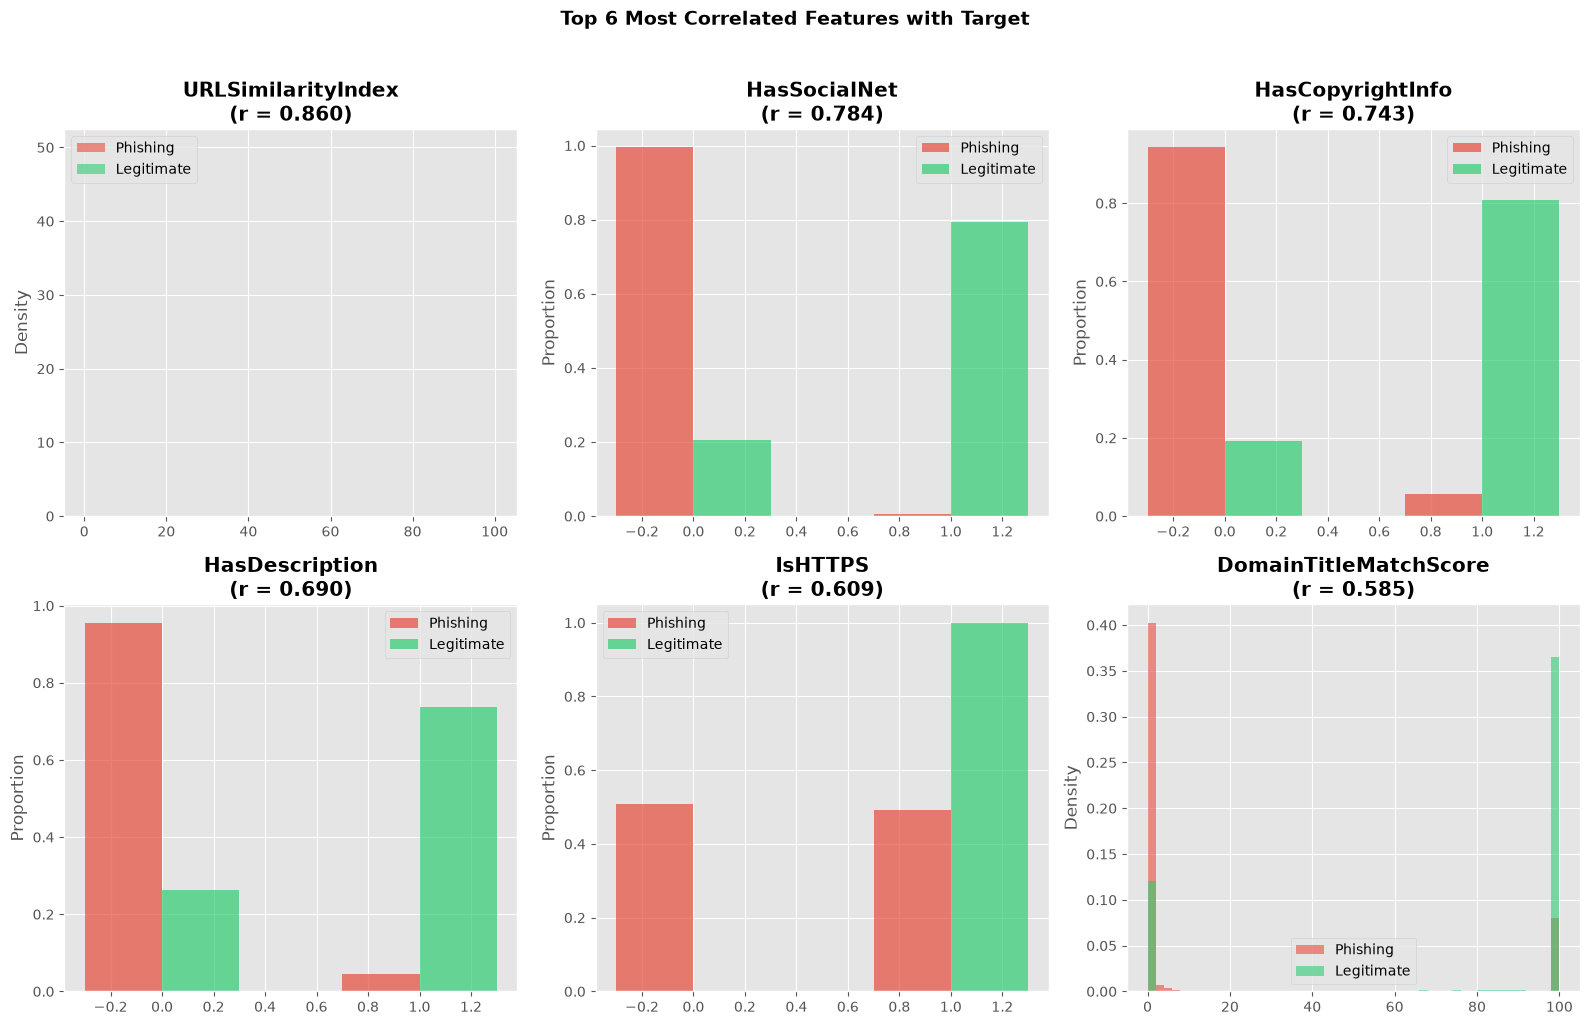

In [16]:
# ambil 6 fitur yang paling berkorelasi dengan target
top_features = target_corr.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    ax = axes[i]
    n_unique = df[feat].nunique()

    for label_val, color, name in [(0, '#e74c3c', 'Phishing'),
                                   (1, '#2ecc71', 'Legitimate')]:
        data = df[df['label'] == label_val][feat]

        if n_unique <= 10:
            # fitur diskrit -> pake bar
            vals = data.value_counts(normalize=True).sort_index()
            offset = -0.15 if label_val == 0 else 0.15
            ax.bar(vals.index + offset, vals.values,
                   width=0.3, color=color, alpha=0.7,
                   label=name)
            ax.set_ylabel('Proportion')
        else:
            # fitur kontinu -> pake histogram
            data = data[data <= data.quantile(0.99)]
            ax.hist(data, bins=50, alpha=0.6,
                    label=name, color=color, density=True)
            ax.set_ylabel('Density')

    r = target_corr[feat]
    ax.set_title(f'{feat}\n(r = {r:.3f})', fontweight='bold')
    ax.legend()

plt.suptitle('Top 6 Most Correlated Features with Target',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../Artifacts/figures/08_top_features_distribution.png',
            bbox_inches='tight')
plt.show()

### 5.10 TLD Analysis

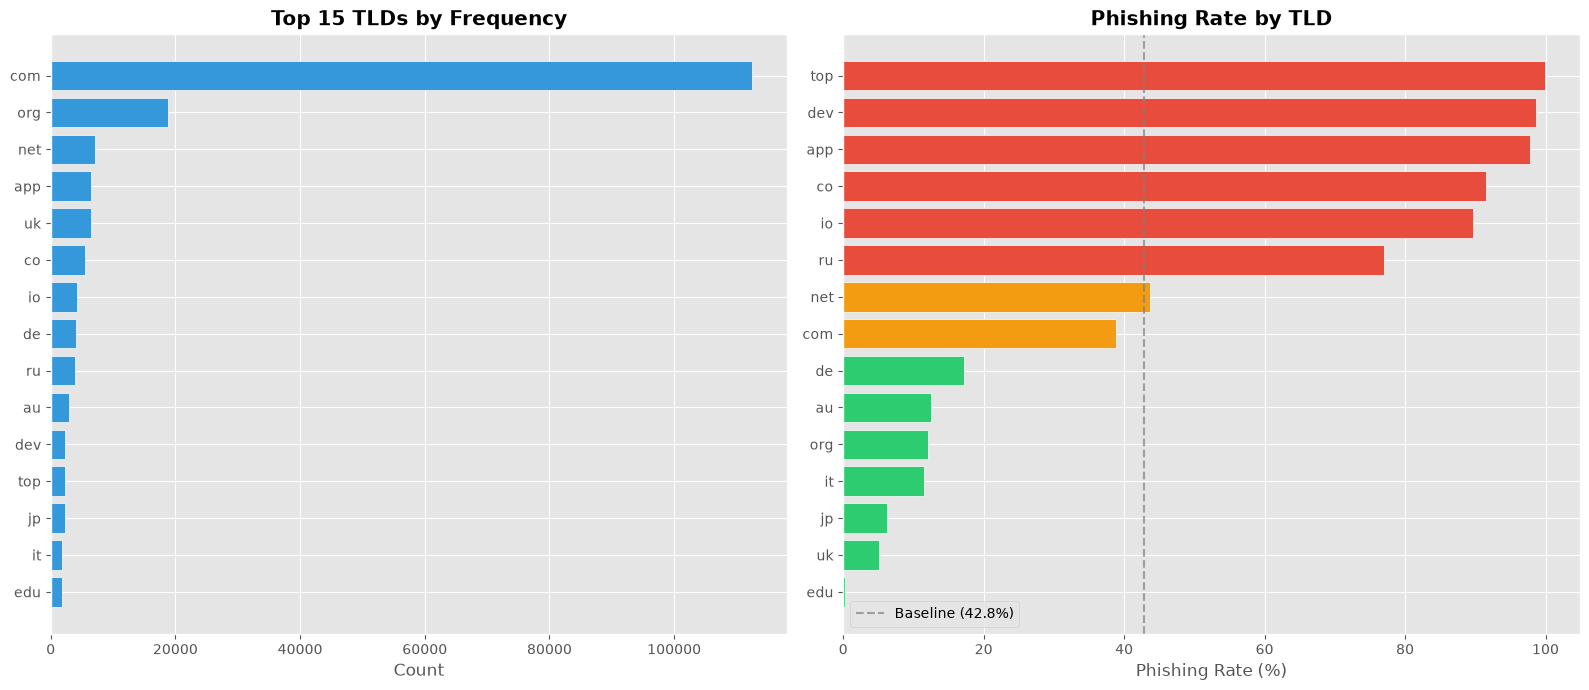

In [17]:
# top 15 TLD
top_tlds = df['TLD'].value_counts().head(15)

# hitung phishing rate per TLD
tld_phishing = df.groupby('TLD')['label'].apply(
    lambda x: (x == 0).mean() * 100
).loc[top_tlds.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# frekuensi TLD
axes[0].barh(top_tlds.index[::-1], top_tlds.values[::-1],
             color='#3498db', edgecolor='white')
axes[0].set_xlabel('Count')
axes[0].set_title('Top 15 TLDs by Frequency', fontweight='bold')

# phishing rate per TLD
sorted_rate = tld_phishing.sort_values(ascending=True)
bar_colors = ['#e74c3c' if r > 50 else '#f39c12' if r > 30
              else '#2ecc71' for r in sorted_rate.values]
axes[1].barh(sorted_rate.index, sorted_rate.values,
             color=bar_colors, edgecolor='white')
axes[1].set_xlabel('Phishing Rate (%)')
axes[1].set_title('Phishing Rate by TLD', fontweight='bold')
axes[1].axvline(x=42.8, color='gray', linestyle='--',
               alpha=0.7, label='Baseline (42.8%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../Artifacts/figures/09_tld_analysis.png',
            bbox_inches='tight')
plt.show()

### 5.11 Security & Interaction Features

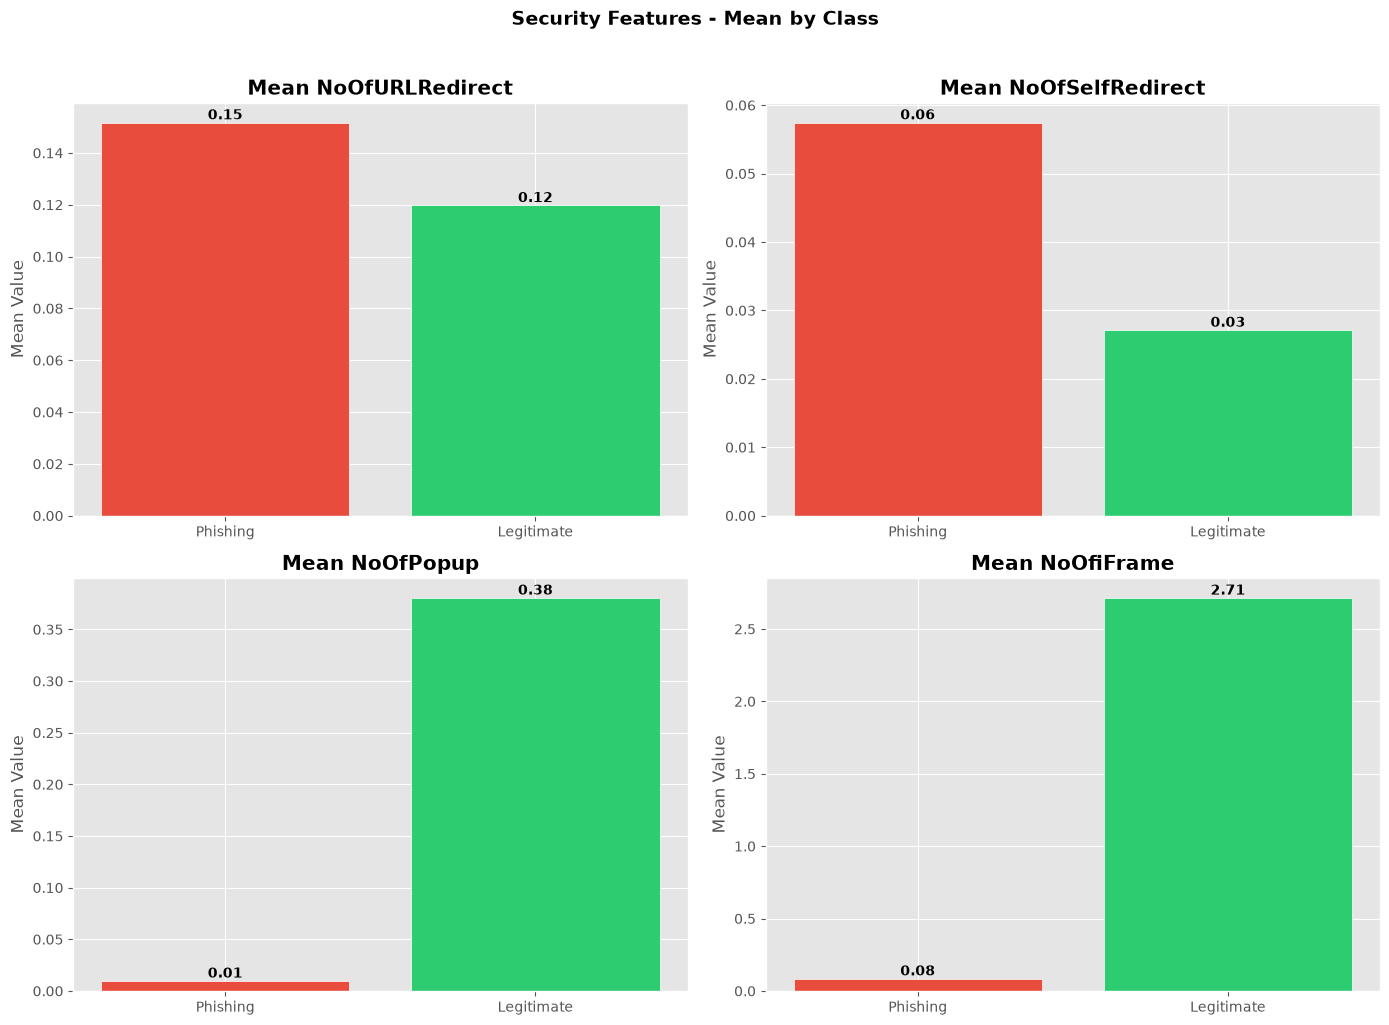

In [18]:
security_features = ['NoOfURLRedirect', 'NoOfSelfRedirect',
                     'NoOfPopup', 'NoOfiFrame']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(security_features):
    ax = axes[i]
    means = df.groupby('label')[feat].mean()
    bars = ax.bar(['Phishing', 'Legitimate'], means.values,
                  color=['#e74c3c', '#2ecc71'], edgecolor='white')

    # tampilin nilainya di atas bar
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height(), f'{val:.2f}',
                ha='center', va='bottom', fontweight='bold')

    ax.set_title(f'Mean {feat}', fontweight='bold')
    ax.set_ylabel('Mean Value')

plt.suptitle('Security Features - Mean by Class',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../Artifacts/figures/10_security_features.png',
            bbox_inches='tight')
plt.show()

### 5.12 Outlier Analysis

In [19]:
# analisis outlier pake IQR method
check_features = ['URLLength', 'DomainLength', 'LineOfCode',
                  'LargestLineLength', 'NoOfImage', 'NoOfCSS',
                  'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef',
                  'NoOfExternalRef', 'NoOfURLRedirect']

outlier_data = []
for feat in check_features:
    q1 = df[feat].quantile(0.25)
    q3 = df[feat].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outliers = ((df[feat] < lower) | (df[feat] > upper)).sum()
    outlier_data.append({
        'Feature': feat,
        'Q1': round(q1, 2),
        'Q3': round(q3, 2),
        'IQR': round(iqr, 2),
        'Outlier Count': n_outliers,
        'Outlier %': round(n_outliers / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_data).sort_values(
    'Outlier %', ascending=False)
print('Outlier Report (IQR Method):')
print(outlier_df.to_string(index=False))

print('\nNote: Tree-based models (RF, XGBoost) robust terhadap outlier.')
print('Outlier removal perlu dipertimbangkan untuk Logistic Regression.')

Outlier Report (IQR Method):
          Feature    Q1     Q3    IQR  Outlier Count  Outlier %
     NoOfEmptyRef   0.0    1.0    1.0          38885      16.49
  NoOfURLRedirect   0.0    0.0    0.0          31464      13.34
  NoOfExternalRef   1.0   57.0   56.0          22780       9.66
        URLLength  23.0   34.0   11.0          22493       9.54
       LineOfCode  18.0 1277.0 1259.0          19280       8.18
        NoOfImage   0.0   29.0   29.0          18362       7.79
          NoOfCSS   0.0    8.0    8.0          17906       7.59
LargestLineLength 200.0 8047.0 7847.0          17503       7.42
      NoOfSelfRef   0.0   88.0   88.0          15576       6.61
     DomainLength  16.0   24.0    8.0          13474       5.71
           NoOfJS   0.0   15.0   15.0          11852       5.03

Note: Tree-based models (RF, XGBoost) robust terhadap outlier.
Outlier removal perlu dipertimbangkan untuk Logistic Regression.


---

## 6. Key Insights & Conclusion

### 6.1 Summary

In [20]:
print('DATASET SUMMARY')
print(f'Total samples  : {len(df):,}')
print(f'Total features : {df.shape[1] - 1}')
print(f'Missing values : 0')
print(f'Duplicates     : 0')
print(f'Class balance  : 57.2% legitimate / 42.8% phishing')
print(f'High corr pairs: {len(high_corr_df)}')

DATASET SUMMARY
Total samples  : 235,795
Total features : 55
Missing values : 0
Duplicates     : 0
Class balance  : 57.2% legitimate / 42.8% phishing
High corr pairs: 4


### 6.2 Key Findings

1. **Data Quality** - Dataset bersih, tidak ada missing values maupun duplikat. Semua 235,795 instance bisa langsung dipakai.

2. **Class Balance** - Dataset moderately imbalanced (~57% Legitimate vs ~43% Phishing). Tidak terlalu parah, tapi tetap perlu stratified splitting dan class weighting.

3. **Fitur Paling Diskriminatif** - Fitur dengan korelasi tertinggi terhadap target antara lain `URLSimilarityIndex`, `CharContinuationRate`, `HasCopyrightInfo`, dan `TLDLegitimateProb`.

4. **Multikolinearitas** - Beberapa pasangan fitur punya korelasi tinggi (contoh: `NoOfLettersInURL` & `URLLength`, `LetterRatioInURL` & `DegitRatioInURL`). Salah satu dari setiap pasangan bisa di-drop saat preprocessing.

5. **Outliers** - Banyak fitur page content (seperti `LineOfCode`, `NoOfImage`) punya outlier signifikan. Tree-based models handle ini dengan baik, tapi Logistic Regression mungkin perlu capping/transformasi.

6. **Kolom Non-Feature** - `FILENAME`, `URL`, `Domain`, `Title` adalah metadata dan harus di-drop. `TLD` bisa dipakai kalau di-encode.

### 6.3 Rekomendasi untuk Preprocessing

- Drop kolom metadata: `FILENAME`, `URL`, `Domain`, `Title`
- Pertimbangkan frequency encoding untuk `TLD`
- Hapus salah satu fitur dari pasangan yang highly correlated
- Gunakan stratified train/test split
- Feature scaling (StandardScaler) untuk Logistic Regression
- Tree-based models tidak perlu scaling/outlier removal